118 images × 39209 neurons
Ultrametricity score: 0.508


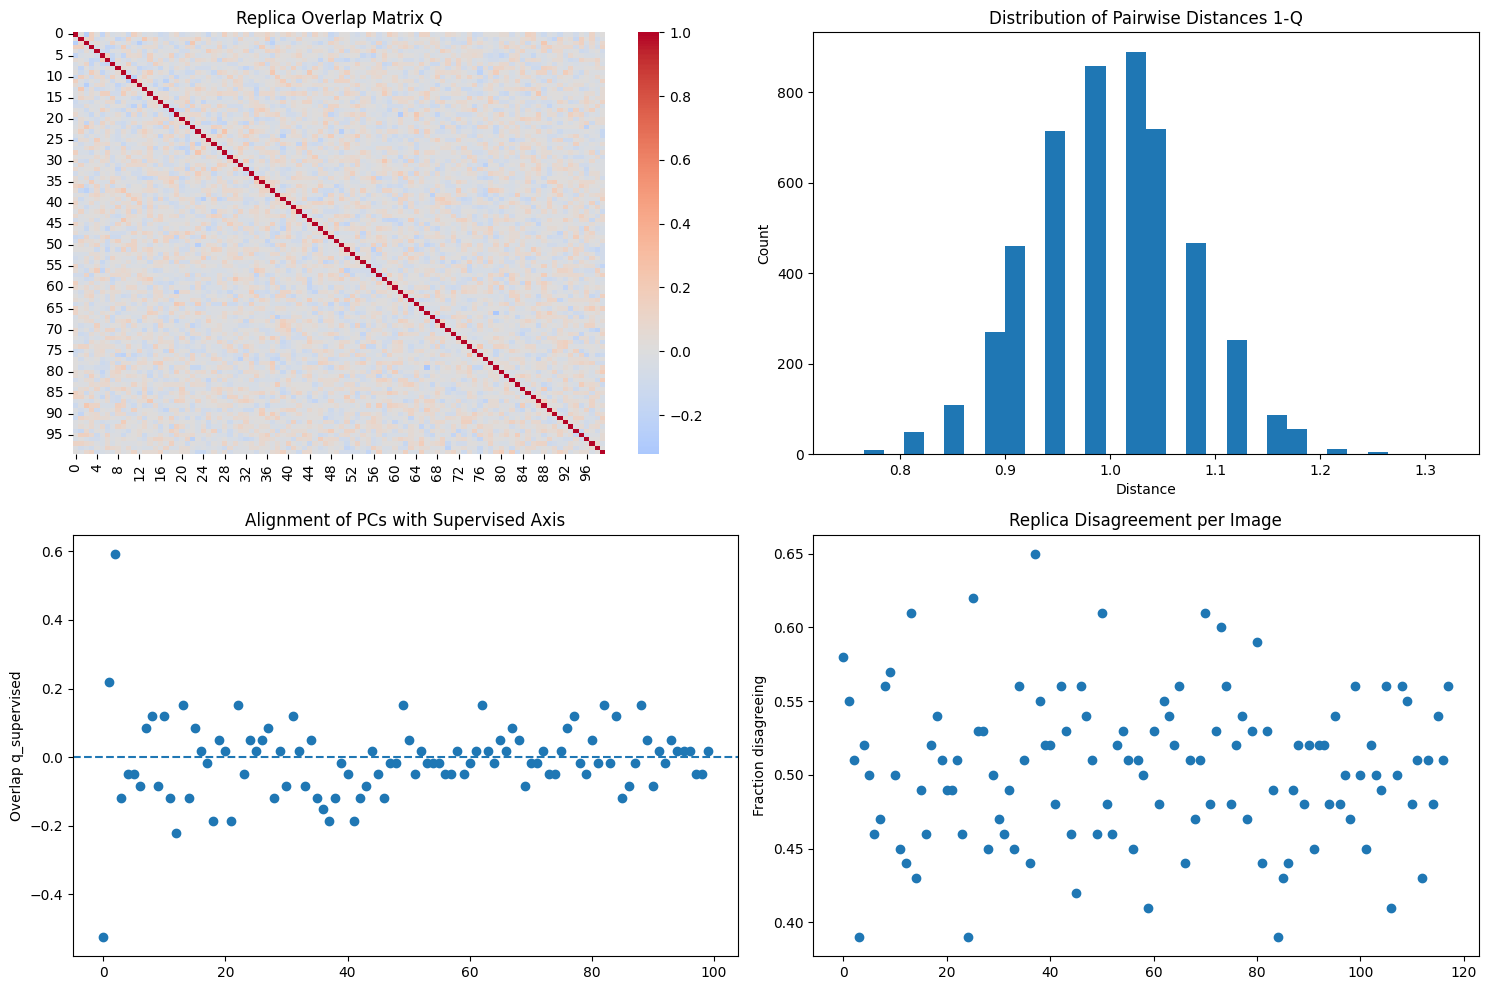

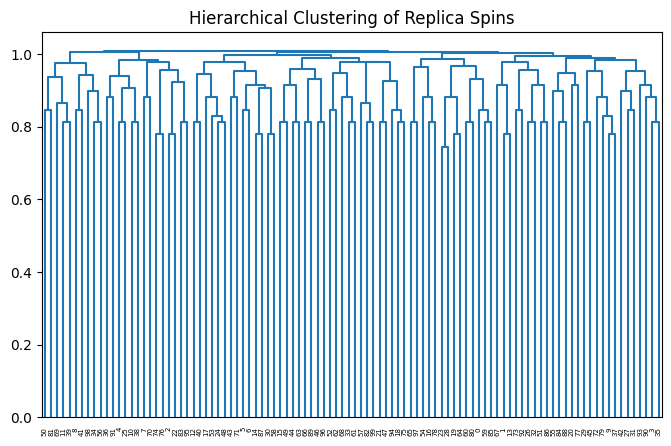

In [2]:


"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# REPLICA SPIN GLASS ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from itertools import combinations
import seaborn as sns

np.random.seed(0)

# ============================================================
# 1) PREPROCESS VIT EMBEDDINGS
# ============================================================

X = vit.copy()  # (images, 1000)
X = StandardScaler().fit_transform(X)

n_images, d = X.shape

# ============================================================
# 2) SUPERVISED LOGISTIC AXIS (animate vs inanimate)
# ============================================================

# Assuming binary labels exist in your workflow
# If not, replace y with your actual labels
y = np.array([1 if i < n_images//2 else 0 for i in range(n_images)])

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

w = clf.coef_.ravel()
b = clf.intercept_[0]

logit_scores = X @ w + b
supervised_spins = np.sign(logit_scores)
supervised_spins[supervised_spins == 0] = 1

# ============================================================
# 3) SEMANTIC PC REPLICAS
# ============================================================

K = 100  # number of PCs (replicas)

pca = PCA(n_components=K)
X_pca = pca.fit_transform(X)

# Median threshold spins
replicas = np.sign(X_pca - np.median(X_pca, axis=0))
replicas[replicas == 0] = 1  # avoid zeros

# replicas shape: (images, K)

# ============================================================
# 4) OVERLAP MATRIX Q
# ============================================================

Q = (replicas.T @ replicas) / n_images  # (K, K)

# ============================================================
# 5) ALIGNMENT WITH SUPERVISED AXIS
# ============================================================

q_supervised = (replicas.T @ supervised_spins) / n_images

# ============================================================
# 6) DISAGREEMENT HOTSPOTS
# ============================================================

# For each image: how many replicas disagree with supervised axis?
disagreement = np.mean(replicas != supervised_spins[:, None], axis=1)

# ============================================================
# 7) ULTRAMETRICITY TEST
# ============================================================

# Distance matrix
D = 1 - Q
tri_indices = np.triu_indices(K, k=1)
dist_values = D[tri_indices]

# Sample random triples
n_triplets = 2000
triplets = np.random.choice(K, size=(n_triplets, 3))

ultra_count = 0
delta = 0.05

for a, b_, c in triplets:
    d_ab = D[a, b_]
    d_ac = D[a, c]
    d_bc = D[b_, c]
    d_sorted = np.sort([d_ab, d_ac, d_bc])
    if abs(d_sorted[2] - d_sorted[1]) < delta:
        ultra_count += 1

ultra_score = ultra_count / n_triplets
print(f"Ultrametricity score: {ultra_score:.3f}")

# ============================================================
# 8) PLOTS
# ============================================================

plt.figure(figsize=(15, 10))

# ---- Heatmap of overlaps ----
plt.subplot(2,2,1)
sns.heatmap(Q, cmap='coolwarm', center=0)
plt.title("Replica Overlap Matrix Q")

# ---- Histogram P(q) ----
plt.subplot(2,2,2)
plt.hist(dist_values, bins=30)
plt.title("Distribution of Pairwise Distances 1-Q")
plt.xlabel("Distance")
plt.ylabel("Count")

# ---- Alignment with supervised axis ----
plt.subplot(2,2,3)
plt.plot(q_supervised, 'o')
plt.axhline(0, linestyle='--')
plt.title("Alignment of PCs with Supervised Axis")
plt.ylabel("Overlap q_supervised")

# ---- Disagreement hotspots ----
plt.subplot(2,2,4)
plt.plot(disagreement, 'o')
plt.title("Replica Disagreement per Image")
plt.ylabel("Fraction disagreeing")

plt.tight_layout()
plt.show()

# ============================================================
# 9) HIERARCHICAL CLUSTERING
# ============================================================

linked = linkage(squareform(D), method='average')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Hierarchical Clustering of Replica Spins")
plt.show()